<a href="https://colab.research.google.com/github/eyedecay/RLImplementations/blob/main/src/brax_mujoco_implementations/SAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

In [ ]:
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [ ]:
from mujoco_playground import registry
config = registry.get_default_config("CartpoleBalance")
env = registry.load("CartpoleBalance", config = config)


In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
state = jit_reset(jax.random.PRNGKey(0))
rollout = [state]

f = 0.5
for i in range(config.episode_length):
  action = []
  for j in range(env.action_size):
    action.append(
        jp.sin(
            state.data.time * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
        )
    )
  action = jp.array(action)
  state = jit_step(state, action)
  rollout.append(state)

frames = env.render(rollout)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 1001/1001 [01:07<00:00, 14.75it/s]


This browser does not support the video tag.


In [ ]:
from mujoco_playground.config import dm_control_suite_params
sac_params = dm_control_suite_params.brax_sac_config('CartpoleBalance')
print(sac_params)

action_repeat: 1
batch_size: 512
discounting: 0.99
episode_length: 1000
grad_updates_per_step: 8
learning_rate: 0.001
max_replay_size: 4194304
min_replay_size: 8192
network_factory:
  q_network_layer_norm: true
normalize_observations: true
num_envs: 128
num_evals: 10
num_resets_per_eval: 10
num_timesteps: 5000000
reward_scaling: 1.0



In [ ]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, sac_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

sac_training_params = dict(sac_params)
sac_training_params.pop("num_resets_per_eval", None)
network_factory = sac_networks.make_sac_networks
if "network_factory" in sac_params:
  del sac_training_params["network_factory"]
  network_factory = functools.partial(
      sac_networks.make_sac_networks,
      **sac_params.network_factory
  )

train_fn = functools.partial(
    sac.train, **dict(sac_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

In [ ]:
import inspect

print(inspect.signature(sac.train))
print()
print(sac_params.keys())

(environment: brax.envs.base.Env, num_timesteps, episode_length: int, wrap_env: bool = True, wrap_env_fn: Optional[Callable[[Any], Any]] = None, action_repeat: int = 1, num_envs: int = 1, num_eval_envs: int = 128, learning_rate: float = 0.0001, discounting: float = 0.9, seed: int = 0, batch_size: int = 256, num_evals: int = 1, normalize_observations: bool = False, max_devices_per_host: Optional[int] = None, reward_scaling: float = 1.0, tau: float = 0.005, min_replay_size: int = 0, max_replay_size: Optional[int] = None, grad_updates_per_step: int = 1, deterministic_eval: bool = False, network_factory: brax.training.types.NetworkFactory[brax.training.agents.sac.networks.SACNetworks] = <function make_sac_networks at 0x785e08dff2e0>, progress_fn: Callable[[int, Mapping[str, jax.Array]], NoneType] = <function <lambda> at 0x785e0561e840>, eval_env: Optional[brax.envs.base.Env] = None, randomization_fn: Optional[Callable[[brax.base.System, jax.Array], Tuple[brax.base.System, brax.base.System]

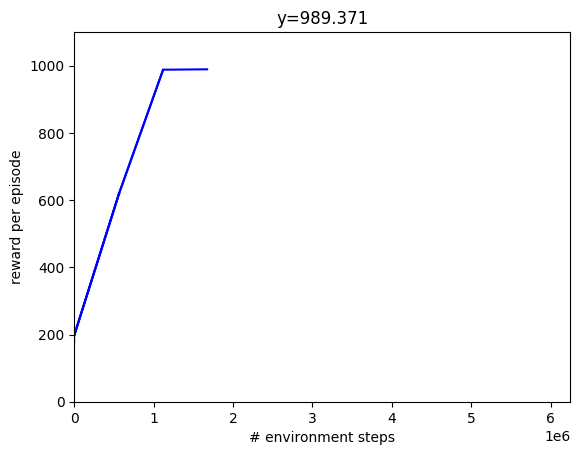

In [ ]:
from mujoco_playground import wrapper

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)